<a href="https://colab.research.google.com/github/sonjoy1s/Deep-Learning/blob/main/Module1_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [10]:
def generate_spiral(n, noise=0.2):
  theta = np.sqrt(np.random.rand(n))*2*np.pi
  r = 2 * theta

  x1 = r * np.cos(theta)+noise*np.random.randn(n)

  x2 = r * np.sin(theta)+noise*np.random.randn(n)

  return np.c_[x1,x2]



X0 = generate_spiral(500)

X1 = -generate_spiral(500)


X = np.vstack([X0,X1])
y = np.array([0]*500 +[1]*500)

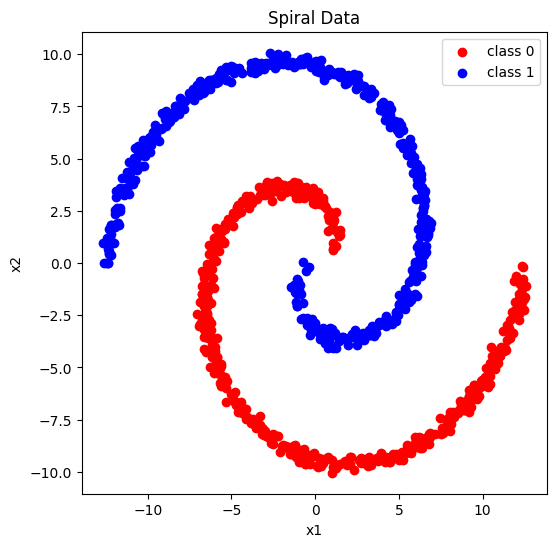

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(X[y==0][:,0], X[y==0][:,1],color='red',label='class 0')
plt.scatter(X[y==1][:,0], X[y==1][:,1],color='blue',label='class 1')
plt.title("Spiral Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


ml_model = LogisticRegression()
ml_model.fit(X_train, y_train)

print("ML Train Accuracy:", ml_model.score(X_train, y_train))
print("ML Test Accuracy :", ml_model.score(X_test, y_test))


ML Train Accuracy: 0.715
ML Test Accuracy : 0.74


In [16]:
d_model = Sequential(
    [
        Dense(256, activation='relu',input_shape=(2,)),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ]
)

d_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

d_model.fit(X_train,y_train,epochs=50,verbose=0)

train_loss, train_acc = d_model.evaluate(X_train,y_train,verbose=0)
test_loss, test_acc = d_model.evaluate(X_test,y_test,verbose=0)

print("DL Train Accuracy:", train_acc)
print("DL Test Accuracy :", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


DL Train Accuracy: 1.0
DL Test Accuracy : 1.0
